In [18]:
import sys
import platform
import importlib.metadata

# --- Début du script de diagnostic ---

print("--- DIAGNOSTIC COMPLET DE L'ENVIRONNEMENT TENSORFLOW ---")
print("-" * 55)

# 1. Informations sur Python
print("1. Version de Python:")
print(f"   - Version: {sys.version.split()[0]}")
print(f"   - Chemin : {sys.executable}\n")

# 2. Informations sur le système d'exploitation
print("2. Système d'exploitation:")
print(f"   - OS      : {platform.system()} {platform.release()}")
print(f"   - Arch.   : {platform.machine()}\n")

# 4. PyTorch & GPU (la partie la plus importante) 
print("\n--- PyTorch & GPU ---")
try:
    import torch
    print(f"Version de PyTorch   : {torch.__version__}")
    
    if torch.cuda.is_available():
        print("Statut GPU           : ✅ GPU NVIDIA détecté et compatible !")
        print(f"Nombre de GPU        : {torch.cuda.device_count()}")
        print(f"Nom du GPU           : {torch.cuda.get_device_name(0)}")
        print(f"Version CUDA (PyTorch): {torch.version.cuda}") # Notez cette version !
    else:
        print("Statut GPU           : ❌ Pas de GPU NVIDIA compatible détecté. PyTorch s'exécutera sur le CPU.")

except ImportError:
    print("Statut PyTorch       : NON INSTALLÉ. Impossible de vérifier la compatibilité GPU.")


# 4. Versions des paquets clés
print("\n4. Versions des bibliothèques du projet :")

packages_to_check = [
    'torch',
    'torchvision',
    'torchaudio',
    'pytorch-lightning',
    'pytorch-forecasting',
    'torchmetrics',
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'optuna',
    'keras-cv',
    'opencv-python',
    'Pillow',
    'jupyter'
]

# Fonction pour afficher la version proprement
def get_package_version(package_name):
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return "--- NON INSTALLÉ ---"

# Affichage des versions
for pkg in packages_to_check:
    print(f"   - {pkg:<25} : {get_package_version(pkg)}")

print("-" * 55)
print("--- FIN DU DIAGNOSTIC ---")

--- DIAGNOSTIC COMPLET DE L'ENVIRONNEMENT TENSORFLOW ---
-------------------------------------------------------
1. Version de Python:
   - Version: 3.11.13
   - Chemin : f:\anaconda\envs\ruban_rose\python.exe

2. Système d'exploitation:
   - OS      : Windows 10
   - Arch.   : AMD64


--- PyTorch & GPU ---
Version de PyTorch   : 2.7.1+cu118
Statut GPU           : ✅ GPU NVIDIA détecté et compatible !
Nombre de GPU        : 1
Nom du GPU           : NVIDIA GeForce RTX 3060 Ti
Version CUDA (PyTorch): 11.8

4. Versions des bibliothèques du projet :
   - torch                     : 2.7.1+cu118
   - torchvision               : 0.22.1+cu118
   - torchaudio                : 2.7.1+cu118
   - pytorch-lightning         : 2.2.5
   - pytorch-forecasting       : 1.4.0
   - torchmetrics              : 1.8.0
   - numpy                     : 2.1.3
   - pandas                    : 2.3.1
   - matplotlib                : 3.10.3
   - seaborn                   : 0.13.2
   - scikit-learn              : 1.7.1

In [19]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [20]:
# --- 1. CONFIGURATION DES CHEMINS ET PARAMÈTRES ---

print("--- Étape 1: Configuration ---")

# Détection automatique du chemin du bureau
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
project_dir = os.path.join(desktop_path, "Ruban_Rose")

# Chemins pour les données
zip_path = os.path.join(project_dir, "bhi.zip")
extract_path = os.path.join(project_dir, "data")
data_dir = os.path.join(extract_path)

# Paramètres du modèle
IMG_SIZE = 224 # ResNet est optimisé pour cette taille
BATCH_SIZE = 32
LEARNING_RATE = 0.00016627342740481045  # Taux d'apprentissage trouvé par Optuna
EPOCHS = 20 # Nombre max d'époques, on arrêtera avant si besoin

# Chemin pour sauvegarder le modèle final
final_model_path = os.path.join(project_dir, "resnet50_pytorch_final.pth")

# Définir le device (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

--- Étape 1: Configuration ---
Utilisation du device : cuda


In [21]:
data_dir

'C:\\Users\\arthu\\Desktop\\Ruban_Rose\\data'

In [22]:
# --- 2. DÉCOMPRESSION DES DONNÉES (si nécessaire) ---
# (Cette partie est identique)
print("\n--- Étape 2: Vérification des données ---")
if not os.path.exists(data_dir):
    print(f"Décompression de {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Décompression terminée.")
else:
    print("Le dossier de données existe déjà.")



--- Étape 2: Vérification des données ---
Le dossier de données existe déjà.


In [23]:
import os
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

src_root = extract_path
# Destination (processed) dataset
dst_root = rf'C:\Users\arthu\Desktop\Ruban_Rose\data_contrast'

def apply_clahe_rgb(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

def process_image(src_dst):
    src_path, dst_path = src_dst
    try:
        img = cv2.imread(src_path)
        if img is None:
            return False
        img_clahe = apply_clahe_rgb(img)
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        cv2.imwrite(dst_path, img_clahe)
        return True
    except:
        return False

# Récupère tous les chemins
all_images = []
for root, _, files in os.walk(src_root):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            src_path = os.path.join(root, file)
            rel_path = os.path.relpath(src_path, src_root)
            dst_path = os.path.join(dst_root, rel_path)
            all_images.append((src_path, dst_path))

print(f"Total images: {len(all_images)}")

# Nombre de threads (tu peux adapter)
num_workers = os.cpu_count() or 4

# Exécution parallèle
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    futures = [executor.submit(process_image, pair) for pair in all_images]
    for _ in tqdm(as_completed(futures), total=len(futures)):
        pass

Total images: 277524


100%|██████████| 277524/277524 [01:58<00:00, 2342.99it/s]


In [24]:
data_dir = dst_root

In [25]:
# --- 3. CRÉATION DU PIPELINE DE DONNÉES (le "DataLoader" PyTorch) ---

print("\n--- Étape 3: Création du pipeline de données PyTorch ---")

import os
from torch.utils.data import Dataset
from PIL import Image
import torch

# L'équivalent du tf.data.Dataset de Keras est une classe Dataset personnalisée
class BreastCancerDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform
        
        print(f"Scanning des sous-dossiers dans {data_dir}...")
        # os.walk parcourt toute l'arborescence, y compris les dossiers patients
        for dirpath, dirnames, filenames in os.walk(data_dir):
            # On ne s'intéresse qu'aux dossiers dont le nom est '0' ou '1'
            if os.path.basename(dirpath) in ['0', '1']:
                label = int(os.path.basename(dirpath))
                for fname in filenames:
                    self.image_paths.append(os.path.join(dirpath, fname))
                    self.labels.append(label)
        print("Scan terminé.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label


# Définir les transformations (redimensionnement, augmentation, conversion en Tenseur)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalisation standard pour ImageNet
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Créer le dataset complet
full_dataset = BreastCancerDataset(data_dir, transform=data_transforms['train'])
print(f"{len(full_dataset)} images trouvées.")

# Division 70/20/10
train_size = int(0.7 * len(full_dataset))
val_size = int(0.2 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Appliquer les bonnes transformations aux datasets de validation/test
val_dataset.dataset.transform = data_transforms['val']
test_dataset.dataset.transform = data_transforms['val']

# Créer les DataLoaders (qui gèrent les lots/batchs)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("DataLoaders prêts.")




--- Étape 3: Création du pipeline de données PyTorch ---
Scanning des sous-dossiers dans C:\Users\arthu\Desktop\Ruban_Rose\data_contrast...
Scan terminé.
277524 images trouvées.
DataLoaders prêts.


DATA AUGMENTATION

In [26]:
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os

class IDCFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    full_path = os.path.join(root, file)
                    label = int(os.path.basename(os.path.dirname(full_path)))
                    self.image_paths.append(full_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
    
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

In [27]:
print(f"{len(data_transforms)} images trouvées.")

2 images trouvées.


In [28]:
dataset = IDCFolderDataset(root_dir=rf"C:\Users\arthu\Desktop\ruban_rose\data_contrast", transform=None)

# Split 80/20
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Ajouter les transforms après le split
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [29]:
full_dataset2 = train_dataset + val_dataset
print(f"{len(dataset)} images trouvées.")

277524 images trouvées.


In [43]:
import time
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

print("\n--- Étape 4: Entraînement avec Fine-Tuning Direct ---")

# --- A. Construction du modèle ---
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

num_ftrs = model.fc.in_features
# MODIFICATION 1 : On retire le Sigmoid final ici car nn.BCEWithLogitsLoss le gère.
model.fc = nn.Sequential(
    nn.Dropout(p=0.30160534019406104),
    nn.Linear(num_ftrs, 1) # La sortie est maintenant un logit brut
)
model = model.to(device)

# --- B. Dégel des couches et définition des hyperparamètres ---
# Dégeler tous les paramètres pour l'entraînement
for param in model.parameters():
    param.requires_grad = True

# Calcul du poids de classe
labels_np = np.array(full_dataset.labels)
neg = np.sum(labels_np == 0)
pos = np.sum(labels_np == 1)
pos_weight = torch.tensor(neg / pos, dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Plus stable que BCELoss + Sigmoid

# MODIFICATION 2 : On crée un seul optimiseur pour tous les paramètres
# (Assure-toi que LEARNING_RATE est défini en amont)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- C. BOUCLE D'ENTRAÎNEMENT UNIQUE ---
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
final_model_path = os.path.join(project_dir, f"resnet50_direct_{timestamp}.pth")
print(f"Le meilleur modèle de cette session sera sauvegardé ici : {final_model_path}")

best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS): # On utilise directement le nombre total d'époques
    start_time = time.time()
    
    # Phase d'entraînement
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        
    # Phase de validation
    model.eval()
    val_loss = 0.0
    corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            # MODIFICATION 3 : Il faut appliquer le sigmoid ici pour l'évaluation
            preds = (torch.sigmoid(outputs) > 0.5).float()
            corrects += torch.sum(preds == labels.data)
            
    # Calcul des métriques et affichage
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = corrects.double() / len(val_dataset)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())
    
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}  | Time: {time.time() - start_time:.2f}s  | Heure de fin: {datetime.now().strftime("%H:%M:%S")}')

    # Sauvegarde du meilleur modèle
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), final_model_path)
        print(f"   -> Nouveau meilleur modèle sauvegardé (Acc: {best_val_acc:.4f})")

print(f"\n✅ Entraînement terminé. Le meilleur modèle est sauvegardé dans '{final_model_path}'")


--- Étape 4: Entraînement avec Fine-Tuning Direct ---
Le meilleur modèle de cette session sera sauvegardé ici : C:\Users\arthu\Desktop\Ruban_Rose\resnet50_direct_20250804-093710.pth
Epoch 1/20 | Train Loss: 0.4210 | Val Loss: 0.3708 | Val Acc: 0.8925  | Time: 1531.70s  | Heure de fin: 10:02:41
   -> Nouveau meilleur modèle sauvegardé (Acc: 0.8925)
Epoch 2/20 | Train Loss: 0.3459 | Val Loss: 0.3490 | Val Acc: 0.9042  | Time: 1528.98s  | Heure de fin: 10:28:11
   -> Nouveau meilleur modèle sauvegardé (Acc: 0.9042)
Epoch 3/20 | Train Loss: 0.2906 | Val Loss: 0.3594 | Val Acc: 0.8891  | Time: 1589.13s  | Heure de fin: 10:54:40
Epoch 4/20 | Train Loss: 0.2207 | Val Loss: 0.3860 | Val Acc: 0.9016  | Time: 1580.83s  | Heure de fin: 11:21:01
Epoch 5/20 | Train Loss: 0.1549 | Val Loss: 0.4284 | Val Acc: 0.9014  | Time: 1429.96s  | Heure de fin: 11:44:51
Epoch 6/20 | Train Loss: 0.1142 | Val Loss: 0.5603 | Val Acc: 0.9035  | Time: 1350.72s  | Heure de fin: 12:07:21
Epoch 7/20 | Train Loss: 0.09


--- Étape 5: Évaluation finale ---

--- Rapport de Classification Final ---
               precision    recall  f1-score   support

     Sain (0)       0.98      0.98      0.98     19813
Cancéreux (1)       0.96      0.96      0.96      7941

     accuracy                           0.98     27754
    macro avg       0.97      0.97      0.97     27754
 weighted avg       0.98      0.98      0.98     27754


--- Matrice de Confusion Finale ---


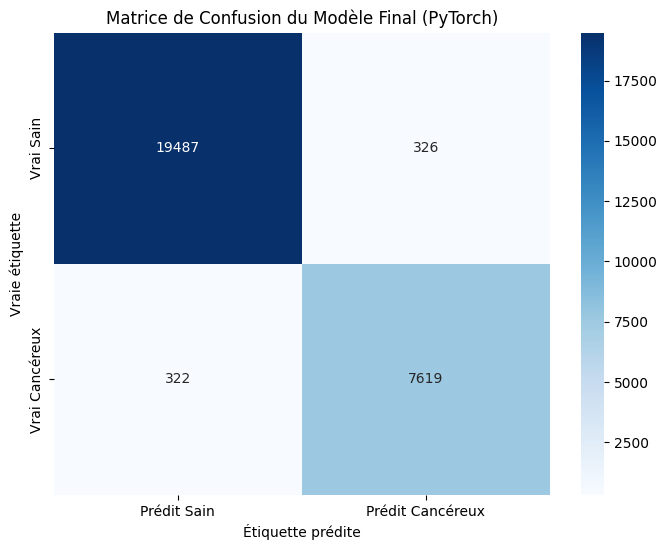

In [44]:
# --- 5. ÉVALUATION FINALE DU MODÈLE ---
print("\n--- Étape 5: Évaluation finale ---")
# Charger le meilleur modèle
model.load_state_dict(torch.load(final_model_path))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
        outputs = model(inputs)
        preds = (outputs > 0.5).float()
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()

# Rapport de classification
print("\n--- Rapport de Classification Final ---")
print(classification_report(y_true, y_pred, target_names=['Sain (0)', 'Cancéreux (1)']))

# Matrice de confusion
print("\n--- Matrice de Confusion Finale ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Prédit Sain', 'Prédit Cancéreux'], yticklabels=['Vrai Sain', 'Vrai Cancéreux'])
plt.ylabel('Vraie étiquette')
plt.xlabel('Étiquette prédite')
plt.title('Matrice de Confusion du Modèle Final (PyTorch)')
plt.show()


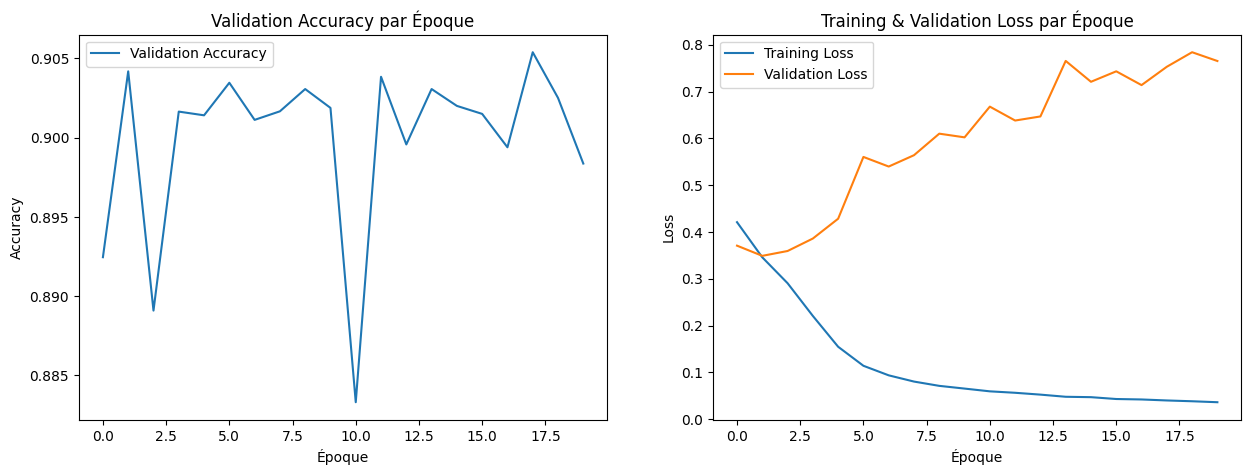

In [45]:
# --- Code pour tracer les graphiques d'apprentissage ---
plt.figure(figsize=(15, 5))

# Graphique de la précision
plt.subplot(1, 2, 1)
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Validation Accuracy par Époque')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()

# Graphique de la perte
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss par Époque')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.show()

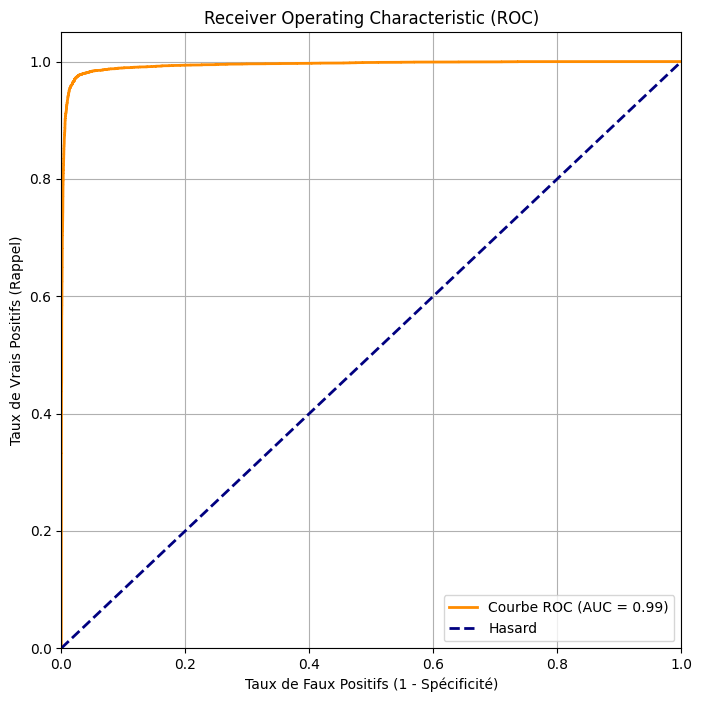

In [46]:
from sklearn.metrics import roc_curve, auc

# Calculer les probabilités prédites (sortie du modèle avant seuillage)
y_pred_proba = []

with torch.no_grad():
	for inputs, labels in test_loader:
		inputs = inputs.to(device)
		outputs = model(inputs)
		y_pred_proba.extend(outputs.cpu().numpy())

y_pred_proba = np.array(y_pred_proba).flatten()

# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Tracer la courbe ROC
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Rappel)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()